In [1]:
from logging import getLogger
from itertools import product
from utils.dataset import RecDataset
from utils.dataloader import TrainDataLoader, EvalDataLoader
from utils.logger import init_logger
from utils.configurator import Config
from utils.utils import init_seed, get_model, get_trainer, dict2str
import platform
import os

/home/minhle/miniconda3/envs/Graph/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
model = 'PGL'
dataset = 'baby'
config_dict = {
    'gpu_id': 0,
}
save_model = True
mg = False

In [3]:
config = Config(model, dataset, config_dict, mg)
init_logger(config)
logger = getLogger()
# print config infor
logger.info('██Server: \t' + platform.node())
logger.info('██Dir: \t' + os.getcwd() + '\n')
logger.info(config)

# load data
dataset = RecDataset(config)
# print dataset statistics
logger.info(str(dataset))

train_dataset, valid_dataset, test_dataset = dataset.split()
logger.info('\n====Training====\n' + str(train_dataset))
logger.info('\n====Validation====\n' + str(valid_dataset))
logger.info('\n====Testing====\n' + str(test_dataset))

07 Dec 01:18    INFO ██Server: 	minhle
07 Dec 01:18    INFO ██Dir: 	/home/minhle/CaMRec/src

07 Dec 01:18    INFO 
gpu_id=0
use_gpu=True
seed=[999]
data_path=../data/
inter_splitting_label=x_label
filter_out_cod_start_users=True
is_multimodal_model=True
checkpoint_dir=saved
save_recommended_topk=True
recommend_topk=recommend_topk/
embedding_size=64
weight_decay=0.0
req_training=True
epochs=1000
stopping_step=20
train_batch_size=2048
learner=adam
learning_rate=0.001
learning_rate_scheduler=[0.96, 50]
eval_step=1
training_neg_sample_num=1
use_neg_sampling=True
use_full_sampling=False
NEG_PREFIX=neg__
USER_ID_FIELD=userID
ITEM_ID_FIELD=itemID
TIME_FIELD=timestamp
field_separator=	
metrics=['Recall', 'NDCG', 'Precision', 'MAP']
topk=[5, 10, 20, 50]
valid_metric=Recall@20
eval_batch_size=4096
use_raw_features=False
max_txt_len=32
max_img_size=256
vocab_size=30522
type_vocab_size=2
hidden_size=4
pad_token_id=0
max_position_embeddings=512
layer_norm_eps=1e-12
hidden_dropout_prob=0.1
end2end=F

In [4]:
train_data = TrainDataLoader(config, train_dataset, batch_size=config['train_batch_size'], shuffle=True)
(valid_data, test_data) = (
    EvalDataLoader(config, valid_dataset, additional_dataset=train_dataset, batch_size=config['eval_batch_size']),
    EvalDataLoader(config, test_dataset, additional_dataset=train_dataset, batch_size=config['eval_batch_size']))

In [5]:
hyper_ret = []
val_metric = config['valid_metric'].lower()
best_test_value = 0.0
idx = best_test_idx = 0
hyper_ls = []
if "seed" not in config['hyper_parameters']:
    config['hyper_parameters'] = ['seed'] + config['hyper_parameters']
for i in config['hyper_parameters']:
    hyper_ls.append(config[i] or [None])
# combinations
combinators = list(product(*hyper_ls))
total_loops = len(combinators)

In [6]:
for i in combinators:
    print(i)

(999, 0.2, 0, 'local')


In [7]:
for j, k in zip(config['hyper_parameters'], combinators[0]):
    config[j] = k
init_seed(config['seed'])

logger.info('========={}/{}: Parameters:{}={}======='.format(
    idx+1, total_loops, config['hyper_parameters'], combinators[0]))

# set random state of dataloader
train_data.pretrain_setup()
# model loading and initialization
model = get_model(config['model'])(config, train_data).to(config['device'])
logger.info(model)

# trainer loading and initialization
trainer = get_trainer()(config, model, mg)

07 Dec 01:18    INFO =========1/1: Parameters:['seed', 'dropout', 'reg_weight', 'mode']=(999, 0.2, 0, 'local')=======


/home/minhle/CaMRec/src/models/pgl.py:136: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /opt/conda/conda-bld/pytorch_1720538459595/work/torch/csrc/utils/tensor_new.cpp:641.)
  return torch.sparse.FloatTensor(i, data, torch.Size((self.n_nodes, self.n_nodes)))
/home/minhle/CaMRec/src/models/pgl.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be lo

In [8]:
best_valid_score, best_valid_result, best_test_upon_valid = trainer.fit(train_data, valid_data=valid_data, test_data=test_data, saved=save_model)


07 Dec 01:18    INFO epoch 0 training [time: 1.56s, train loss: 36.9737]
07 Dec 01:18    INFO epoch 0 evaluating [time: 1.34s, valid_score: 0.050800]
07 Dec 01:18    INFO valid result: 
recall@5: 0.0212    recall@10: 0.0326    recall@20: 0.0508    recall@50: 0.0888    ndcg@5: 0.0141    ndcg@10: 0.0178    ndcg@20: 0.0224    ndcg@50: 0.0300    precision@5: 0.0045    precision@10: 0.0034    precision@20: 0.0027    precision@50: 0.0019    map@5: 0.0115    map@10: 0.0130    map@20: 0.0142    map@50: 0.0154    
07 Dec 01:18    INFO test result: 
recall@5: 0.0195    recall@10: 0.0331    recall@20: 0.0521    recall@50: 0.0901    ndcg@5: 0.0133    ndcg@10: 0.0177    ndcg@20: 0.0227    ndcg@50: 0.0303    precision@5: 0.0044    precision@10: 0.0037    precision@20: 0.0029    precision@50: 0.0020    map@5: 0.0108    map@10: 0.0126    map@20: 0.0139    map@50: 0.0151    
07 Dec 01:18    INFO ██ PGL--Best validation results updated!!!
07 Dec 01:18    INFO epoch 1 training [time: 1.33s, train loss: 3

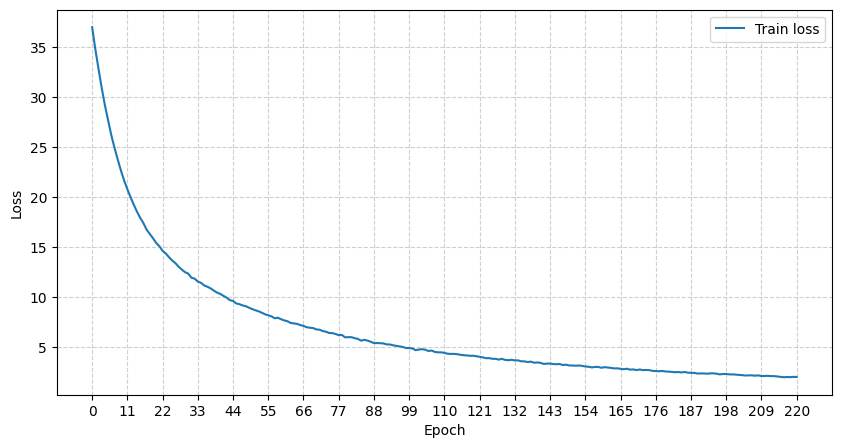

<Figure size 640x480 with 0 Axes>

In [9]:
trainer.plot_train_loss(figsize=(10,5), markersize=0)

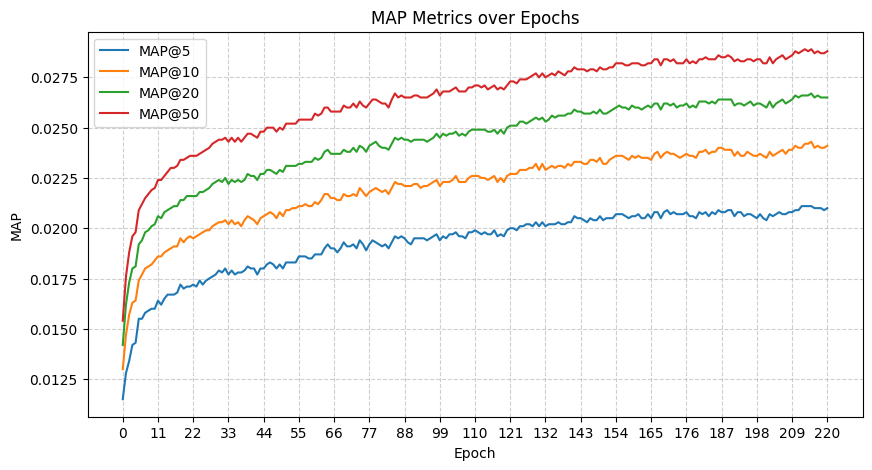

In [10]:
trainer.plot_map(figsize=(10,5), markersize=0)

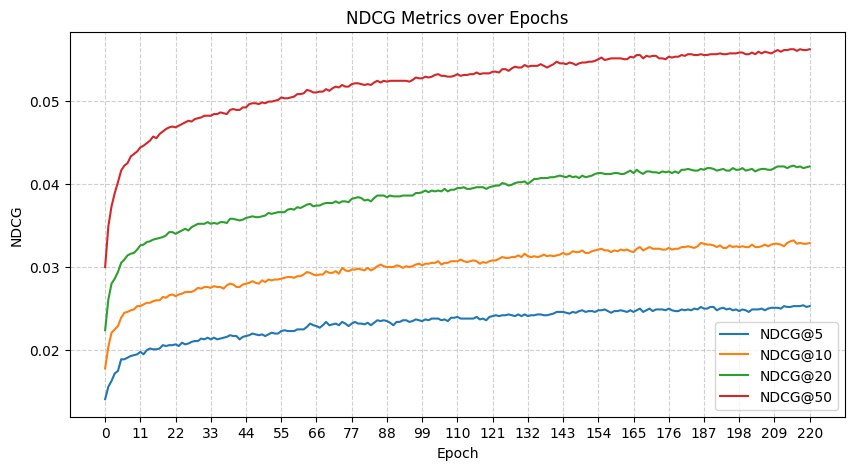

In [11]:
trainer.plot_ndcg(figsize=(10,5), markersize=0)

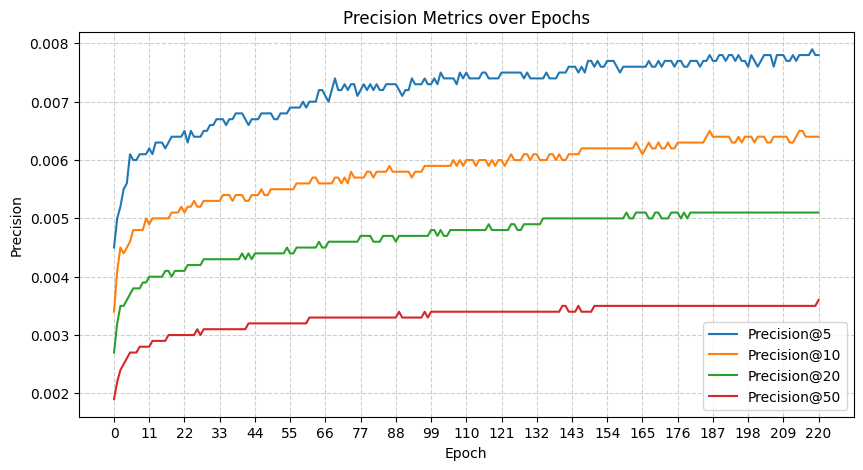

In [12]:
trainer.plot_precision(figsize=(10,5), markersize=0)

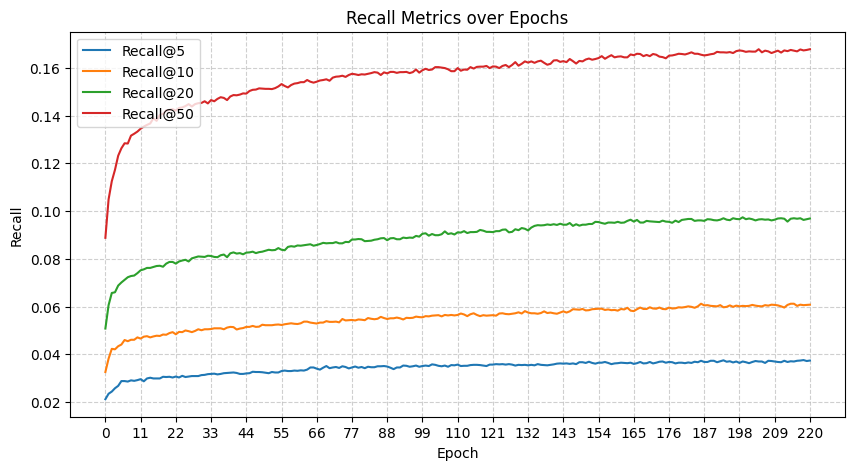

In [13]:
trainer.plot_recall(figsize=(10,5), markersize=0)

In [14]:
hyper_ret.append((combinators[0], best_valid_result, best_test_upon_valid))

# save best test
if best_test_upon_valid[val_metric] > best_test_value:
    best_test_value = best_test_upon_valid[val_metric]
    best_test_idx = idx
idx += 1

logger.info('best valid result: {}'.format(dict2str(best_valid_result)))
logger.info('test result: {}'.format(dict2str(best_test_upon_valid)))
logger.info('████Current BEST████:\nParameters: {}={},\n'
            'Valid: {},\nTest: {}\n\n\n'.format(config['hyper_parameters'],
    hyper_ret[best_test_idx][0], dict2str(hyper_ret[best_test_idx][1]), dict2str(hyper_ret[best_test_idx][2])))


07 Dec 01:33    INFO best valid result: recall@5: 0.0370    recall@10: 0.0603    recall@20: 0.0974    recall@50: 0.1671    ndcg@5: 0.0249    ndcg@10: 0.0325    ndcg@20: 0.0419    ndcg@50: 0.0558    precision@5: 0.0078    precision@10: 0.0064    precision@20: 0.0051    precision@50: 0.0035    map@5: 0.0207    map@10: 0.0237    map@20: 0.0262    map@50: 0.0284    
07 Dec 01:33    INFO test result: recall@5: 0.0396    recall@10: 0.0631    recall@20: 0.0997    recall@50: 0.1689    ndcg@5: 0.0262    ndcg@10: 0.0339    ndcg@20: 0.0433    ndcg@50: 0.0572    precision@5: 0.0087    precision@10: 0.0070    precision@20: 0.0055    precision@50: 0.0037    map@5: 0.0211    map@10: 0.0242    map@20: 0.0267    map@50: 0.0289    
07 Dec 01:33    INFO ████Current BEST████:
Parameters: ['seed', 'dropout', 'reg_weight', 'mode']=(999, 0.2, 0, 'local'),
Valid: recall@5: 0.0370    recall@10: 0.0603    recall@20: 0.0974    recall@50: 0.1671    ndcg@5: 0.0249    ndcg@10: 0.0325    ndcg@20: 0.0419    ndcg@50: 